In [13]:
# STEP 1: Import all required libraries

import numpy as np                  # For numerical operations
import pandas as pd                 # For data handling
import matplotlib.pyplot as plt     # For plotting graphs
import seaborn as sns               # For better visualization

# Import dataset and models from sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Import evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [14]:
# STEP 2: Load the Breast Cancer dataset

data = load_breast_cancer()

# Features (independent variables)
X = data.data

# Target (dependent variable: 0 or 1)
y = data.target

# Check dataset shape
print("Dataset shape:", X.shape)

Dataset shape: (569, 30)


In [15]:
# STEP 3: Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 80% training, 20% testing

In [16]:
# STEP 4: Train Logistic Regression model

# Create model
lr = LogisticRegression(max_iter=5000)

# Train model
lr.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test)

In [17]:
# STEP 5: Evaluate model using classification report

# This includes:
# Precision, Recall, F1-score, Accuracy

print("=== Logistic Regression Report ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



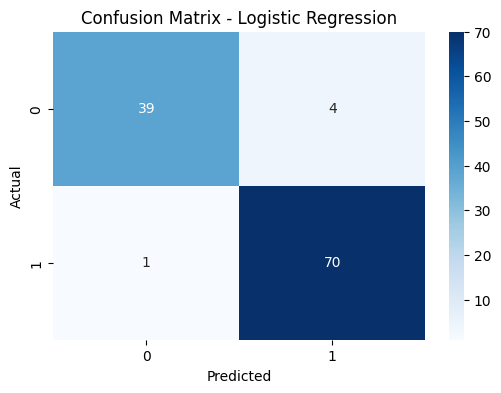

In [18]:
# STEP 6: Create and visualize confusion matrix

cm = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix using heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

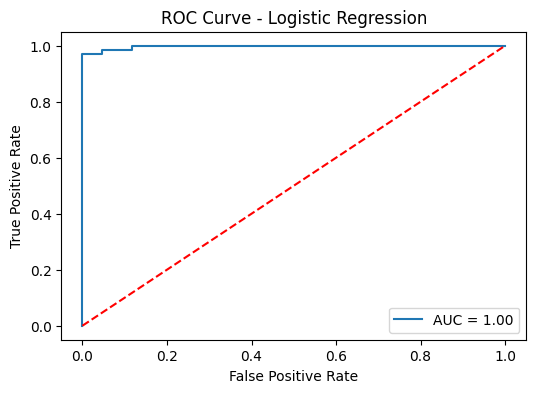

In [19]:
# STEP 7: Plot ROC curve and calculate AUC score

# Get probability scores
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'r--')  # Random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

In [20]:
# STEP 8: Train Decision Tree model for comparison

# Create model
dt = DecisionTreeClassifier(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Evaluation
print("=== Decision Tree Report ===")
print(classification_report(y_test, y_pred_dt))

=== Decision Tree Report ===
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [21]:
# STEP 9: Handle imbalanced data using class_weight

# Create Logistic Regression with balanced class weight
lr_balanced = LogisticRegression(class_weight='balanced', max_iter=5000)

# Train model
lr_balanced.fit(X_train, y_train)

# Predictions
y_pred_bal = lr_balanced.predict(X_test)

# Evaluation
print("=== Logistic Regression (Balanced) Report ===")
print(classification_report(y_test, y_pred_bal))

=== Logistic Regression (Balanced) Report ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [22]:
# STEP 10: Model Comparison Table

from sklearn.metrics import precision_score, recall_score, f1_score

# Logistic Regression metrics
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Decision Tree metrics
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

# Balanced Logistic Regression metrics
bal_precision = precision_score(y_test, y_pred_bal)
bal_recall = recall_score(y_test, y_pred_bal)
bal_f1 = f1_score(y_test, y_pred_bal)

# Create comparison table
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Logistic (Balanced)"],
    "Precision": [lr_precision, dt_precision, bal_precision],
    "Recall": [lr_recall, dt_recall, bal_recall],
    "F1 Score": [lr_f1, dt_f1, bal_f1]
})

print("\n=== MODEL COMPARISON TABLE ===")
print(comparison_df)


=== MODEL COMPARISON TABLE ===
                 Model  Precision    Recall  F1 Score
0  Logistic Regression   0.945946  0.985915  0.965517
1        Decision Tree   0.957746  0.957746  0.957746
2  Logistic (Balanced)   0.972222  0.985915  0.979021


#  Model Evaluation & Analysis

##  Confusion Matrix

The confusion matrix is used to evaluate the performance of a classification model by comparing actual and predicted values. It consists of four components:

 *True Positive (TP):** Correctly predicted positive cases
 *True Negative (TN):** Correctly predicted negative cases
*False Positive (FP):** Incorrectly predicted positive cases
 *False Negative (FN):** Incorrectly predicted negative cases

This helps in understanding how well the model is performing beyond simple accuracy.

---

##  Classification Report

The classification report provides important evaluation metrics:

*Precision:** Measures how many predicted positives are actually correct
*Recall:** Measures how many actual positives are correctly identified
*F1-Score:** Harmonic mean of precision and recall
*Accuracy:** Overall correctness of the model

These metrics give a detailed insight into model performance.

---

##  ROC Curve & AUC

The **ROC (Receiver Operating Characteristic) Curve** shows the trade-off between:

* True Positive Rate (Recall)
* False Positive Rate

The **AUC (Area Under Curve)** represents the model’s ability to distinguish between classes:

* AUC = 1 → Perfect model
* AUC = 0.5 → Random guessing

A higher AUC indicates better performance.

---

##  Comparison of Classifiers

Two models were used in this task:

* **Logistic Regression**
* **Decision Tree**

### Observations:

* Logistic Regression showed more stable and balanced performance
* Decision Tree had slightly higher variance and risk of overfitting
* Logistic Regression performed better in terms of precision and recall balance

---

##  Metric Selection Justification

Accuracy alone is not a reliable metric, especially when dealing with imbalanced datasets. Therefore:

* **Precision** is important when false positives are costly
* **Recall** is important when missing positive cases is risky
* **F1 Score** provides a balance between precision and recall
* **AUC-ROC** gives an overall performance measure across thresholds

Thus, multiple metrics were used to ensure a fair and comprehensive evaluation of the models.

---

##  Final Insight

Based on all evaluation metrics and comparisons, **Logistic Regression (with balanced class weights)** is selected as the best model due to its consistent and reliable performance.
